# Phase 3: Decision Tree Model Implementation (Information-Based)
In this phase, we load our cleaned dataset, perform a Train/Test split, apply SMOTE **ONLY** to the training data to prevent leakage, and then train and evaluate our Decision Tree.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

print("Loading preprocessed (imbalanced) dataset from Phase 2...")
df = pd.read_csv('../outputs/processed_imbalanced_data.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

Loading preprocessed (imbalanced) dataset from Phase 2...
Loaded 502,346 rows and 80 columns.


### Step 1: Train/Test Split
We MUST split the data *before* balancing to ensure the Test set remains an untouched representation of the real world.

In [ ]:
X = df.drop('Severity', axis=1)
y = df['Severity']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set (Before SMOTE): {X_train.shape[0]:,} rows.")
print(f"Testing set (Untouched):  {X_test.shape[0]:,} rows.")

Training set (Before SMOTE): 401,876 rows.
Testing set (Untouched):  100,470 rows.


### Step 2: Apply SMOTE to Training Data ONLY
We will boost the minority classes (like Fatal) so the model pays attention to them.

In [3]:
print("Applying SMOTE to training data ONLY...")
# We use a softer sampling strategy instead of perfect 1:1:1:1 to reduce noise
# This tells SMOTE to balance the classes without necessarily making them completely equal if it causes too much distortion.
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Training set (After SMOTE): {X_train_balanced.shape[0]:,} rows.")

Applying SMOTE to training data ONLY...
Training set (After SMOTE): 1,280,428 rows.


### Step 3: Train the Model
We limit `max_depth=15` to prevent the tree from overfitting the massive dataset.

In [4]:
print("Training Decision Tree Model on balanced data...")
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)
print("Training Complete!")

Training Decision Tree Model on balanced data...
Training Complete!


### Step 4: Evaluate on the UNTOUCHED Test Set
Calculating our core metrics on real-world data.

In [5]:
# Crucial: We predict on X_test, which has NEVER seen SMOTE
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)

print("--- Decision Tree Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")

--- Decision Tree Evaluation Metrics ---
Accuracy:  0.4691
Precision: 0.7638
Recall:    0.4691
F1 Score:  0.5436


### Confusion Matrix
Visualizing exactly where the model succeeded and where it got confused on the real-world test data.

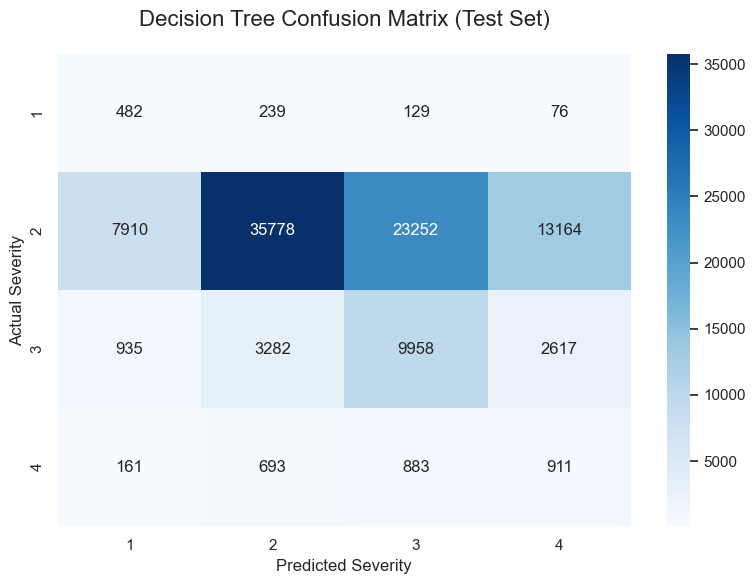

In [6]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1, 2, 3, 4], 
            yticklabels=[1, 2, 3, 4])

plt.title('Decision Tree Confusion Matrix (Test Set)', fontsize=16, pad=20)
plt.ylabel('Actual Severity', fontsize=12)
plt.xlabel('Predicted Severity', fontsize=12)
plt.show()

### ROC Curve
Plotting the ROC curve for the Fatal Class (Severity 4) vs All others.

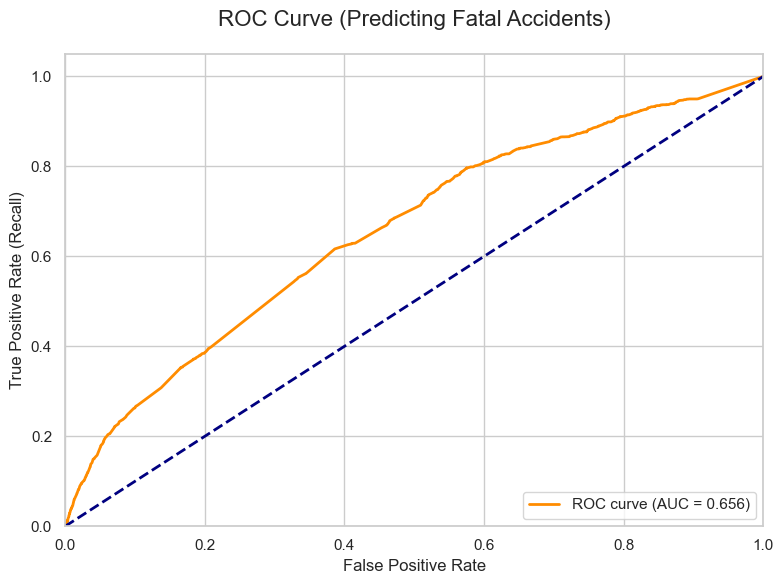

In [7]:
# Binarize the output for plotting Severity 4 (Fatal) vs Rest
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
# Index 3 is Severity 4
y_test_fatal = y_test_bin[:, 3]
y_prob_fatal = y_prob[:, 3]

fpr, tpr, _ = roc_curve(y_test_fatal, y_prob_fatal)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve (Predicting Fatal Accidents)', fontsize=16, pad=20)
plt.legend(loc="lower right")
plt.show()

### Visualization 1: Feature Importances
Showing which variables the Decision Tree relied on the most to make its rules.

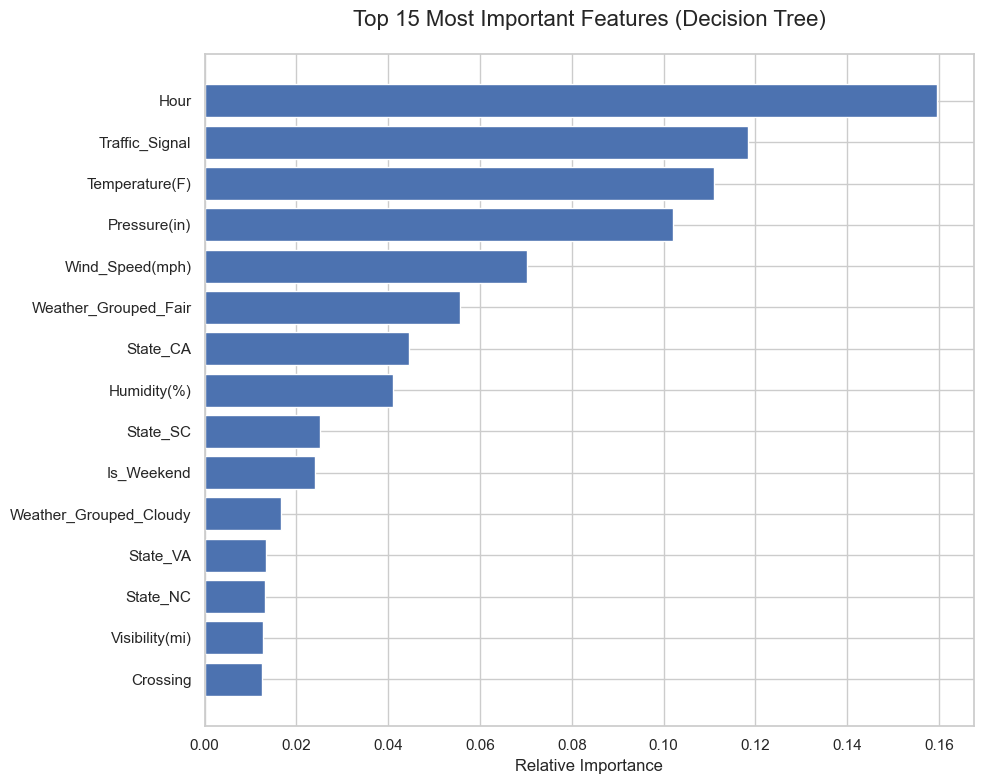

In [8]:
plt.figure(figsize=(10, 8))

importances = dt_model.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 features

plt.title('Top 15 Most Important Features (Decision Tree)', fontsize=16, pad=20)
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X_train_balanced.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Visualization 2: The Decision Tree
Plotting a simplified version (top 3 depths) of the actual tree so we can visually see the IF/THEN rules.

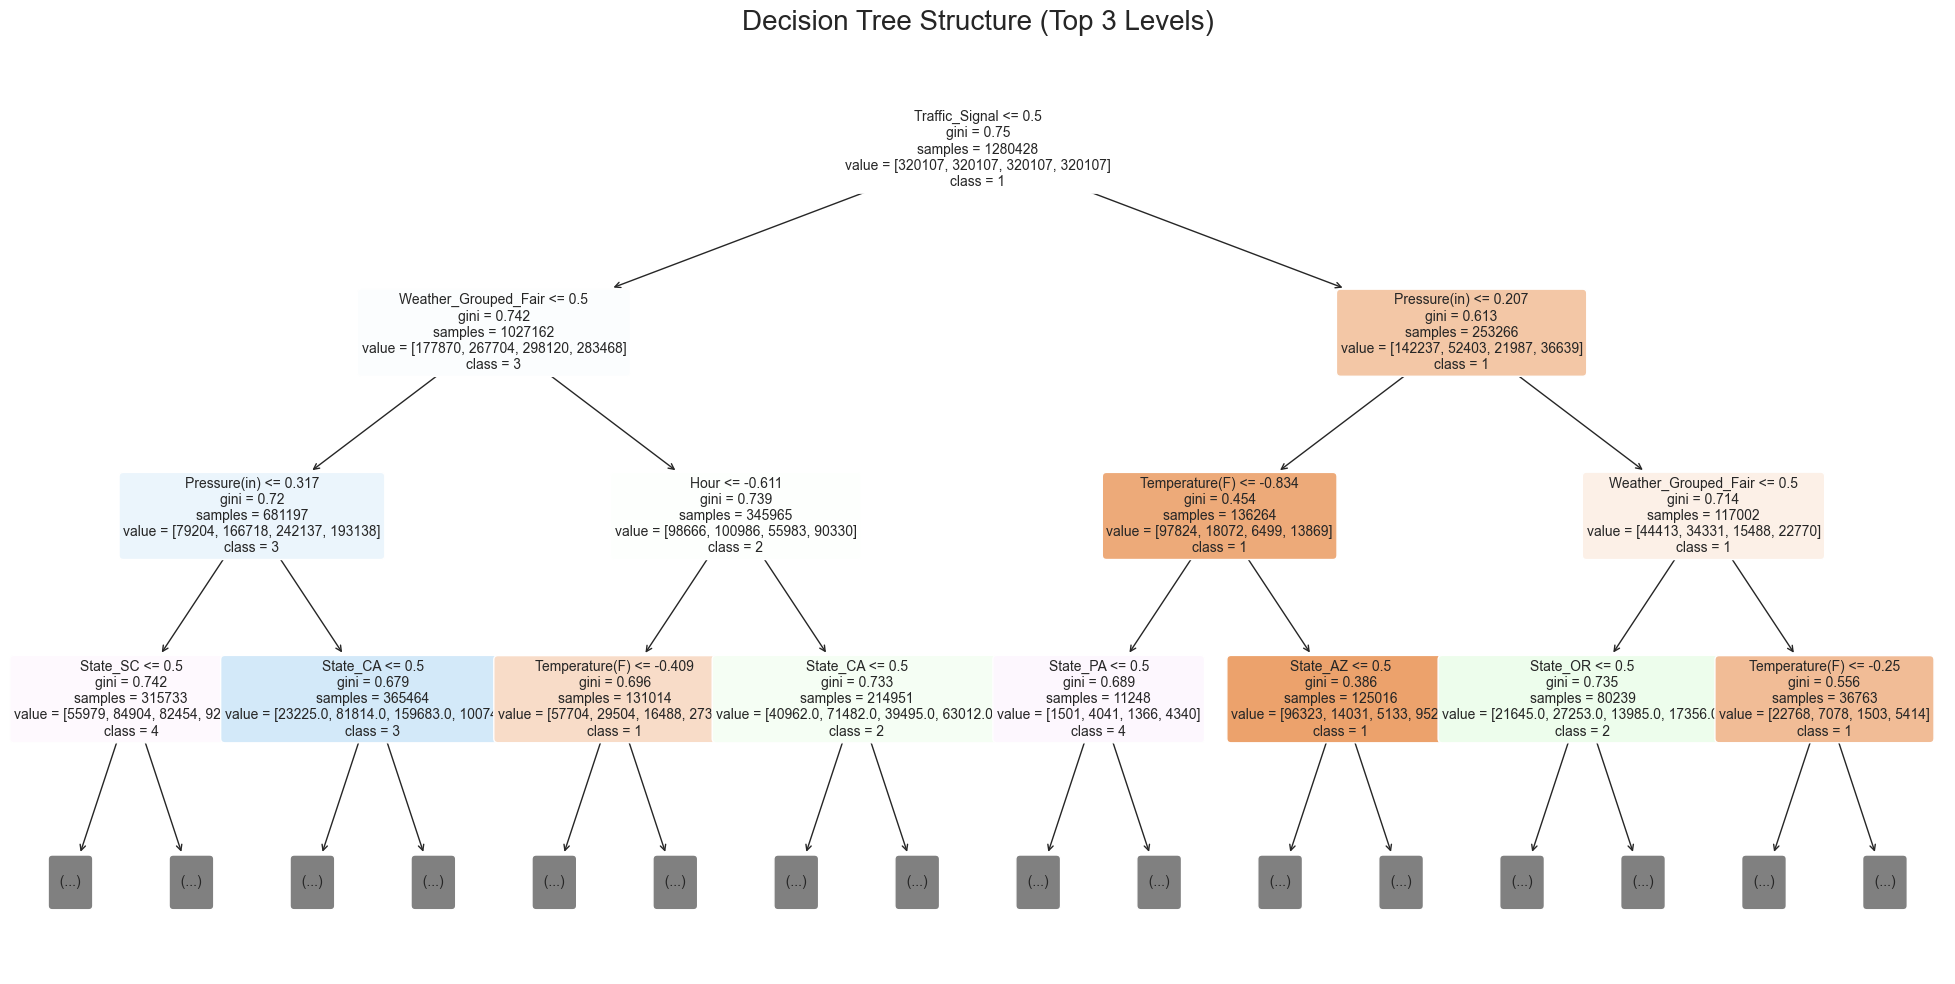

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          max_depth=3, 
          feature_names=X_train_balanced.columns, 
          class_names=['1', '2', '3', '4'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=20, pad=20)
plt.show()